
#  INT303 Big Data Analytics


## Lab 2 Data Preprocessing

**XJTLU**<br>
**S1 2025**<br>
**Instructors:** Pengfei Fan <br>
* 1. Importing Libraries 
* 2. Importing and Exploration of the dataset
* 3. Checking the datatypes of the columns
* 4. Converting the data types of columns
* 5. Summary Statistics of the data
* 6. Missing Values
* 7. Outliers Treatment
* 8. Encoding the Categorical Features
* 9. Creating new Derived Features

### 1. Importing Libraries 

In [121]:
# 'os' module provides functions for interacting with the operating system 
import os

# 'Numpy' is used for mathematical operations on large, multi-dimensional arrays and matrices
import numpy as np

# 'Pandas' is used for data manipulation and analysis
import pandas as pd

# 'Matplotlib' is a data visualization library for 2D and 3D plots, built on numpy
from matplotlib import pyplot as plt
%matplotlib inline

# 'Seaborn' is based on matplotlib; used for plotting statistical graphics
import seaborn as sns

# to suppress warnings
import warnings
warnings.filterwarnings("ignore") 

### 2. Importing and Exploration of the dataset

In [69]:
# loading the data and setting the unique client_id as the index::

df = pd.read_csv('loans.csv', index_col = 'client_id')

df = pd.read_csv('loans.csv')

In [70]:
# # showing the first 5 rows of the dataset:
df.head()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13


In [71]:
# To check the Dimensions of the dataset:
df.shape

(443, 8)

In [72]:
# Checking the info of the data:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   client_id    443 non-null    int64  
 1   loan_type    443 non-null    object 
 2   loan_amount  443 non-null    int64  
 3   repaid       443 non-null    int64  
 4   loan_id      443 non-null    int64  
 5   loan_start   443 non-null    object 
 6   loan_end     443 non-null    object 
 7   rate         443 non-null    float64
dtypes: float64(1), int64(4), object(3)
memory usage: 27.8+ KB


### 3. Checking the datatypes of the columns

In [73]:
df.dtypes

client_id        int64
loan_type       object
loan_amount      int64
repaid           int64
loan_id          int64
loan_start      object
loan_end        object
rate           float64
dtype: object

### 4. Converting the data types of columns

    - loan_id to object
    - repaid to category dtype
    - loan_start and loan_end to date type

In [122]:
# loan_id:

df['loan_id'] = df['loan_id'].astype('object')

# repaid:

df['repaid'] = df['repaid'].astype('category')

In [87]:
# loan_start:

df['loan_start'] = pd.to_datetime(df['loan_start'], format = '%Y-%m-%d')


# loan_end:

df['loan_end'] = pd.to_datetime(df['loan_end'], format = '%Y-%m-%d')

#### Checking the datatypes again:

In [76]:
df.dtypes

client_id               int64
loan_type              object
loan_amount             int64
repaid               category
loan_id                object
loan_start     datetime64[ns]
loan_end       datetime64[ns]
rate                  float64
dtype: object

### 5. Summary Statistics of the data

In [77]:
# Summary Statistics for Numerical data:
df.describe()

,client_id,loan_amount,loan_start,loan_end,rate
count,443.000000,443.000000,443,443,443.000000
mean,38911.060948,7982.311512,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536,3.217156
min,25707.000000,559.000000,2000-01-26 00:00:00,2001-08-02 00:00:00,0.010000
25%,32885.000000,4232.500000,2003-10-19 00:00:00,2005-09-12 12:00:00,1.220000
50%,39505.000000,8320.000000,2007-03-10 00:00:00,2009-03-19 00:00:00,2.780000
75%,46109.000000,11739.000000,2011-07-31 00:00:00,2013-09-11 12:00:00,4.750000
max,49624.000000,14971.000000,2014-11-11 00:00:00,2017-05-07 00:00:00,12.620000
std,7768.681063,4172.891992,NaN,NaN,2.397168


In [78]:
# Summary Statistics for Categorical data:
df.describe(exclude=[np.number])

,loan_type,repaid,loan_id,loan_start,loan_end
count,443,443.0,443.0,443,443
unique,4,2.0,443.0,NaN,NaN
top,home,1.0,10243.0,NaN,NaN
freq,121,237.0,1.0,NaN,NaN
mean,NaN,NaN,NaN,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536
min,NaN,NaN,NaN,2000-01-26 00:00:00,2001-08-02 00:00:00
25%,NaN,NaN,NaN,2003-10-19 00:00:00,2005-09-12 12:00:00
50%,NaN,NaN,NaN,2007-03-10 00:00:00,2009-03-19 00:00:00
75%,NaN,NaN,NaN,2011-07-31 00:00:00,2013-09-11 12:00:00
max,NaN,NaN,NaN,2014-11-11 00:00:00,2017-05-07 00:00:00


### 6. Missing Values

In [79]:
# use isnull().sum() to check for missing values 
df.isnull().sum() 

client_id      0
loan_type      0
loan_amount    0
repaid         0
loan_id        0
loan_start     0
loan_end       0
rate           0
dtype: int64

There are no missing values in the data. 

Sk-learn library has an in-built function called Iterative Imputer to impute the missing values. Its sklearn domcumentation: https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html

----------------

### 7. Outliers Treatment

To check for the presence of outliers, we plot Boxplot.

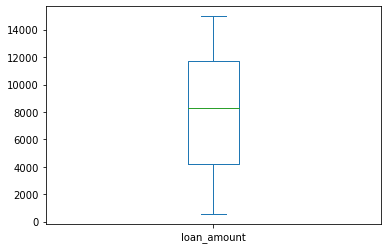

In [80]:
# For loan_amount 
df['loan_amount'].plot(kind='box')
plt.show()

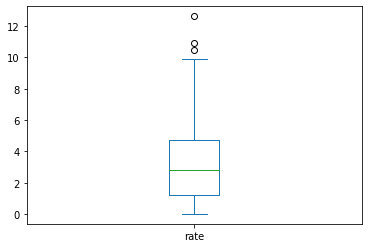

In [81]:
# For rate 
df['rate'].plot(kind='box')
plt.show()

We can see that there are no outliers in the loan_amount column and some outliers are present in the rate column. To treat for outliers can either cap the values or transform the data. Shall demonstrate in Next Week. 

### 8. Encoding the Categorical Features

There are two ways to encode the categorical data into dummyvariables. Using: 

1) pd.get_dummies
2) sklearn's in-built function LabelEncoder

In [27]:
# Loans data:

df_loans = df.copy()

In [28]:
df_loans.head()

,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
client_id,,,,,,,
46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13


In [10]:
df_loans.dtypes

loan_type       object
loan_amount      int64
repaid           int64
loan_id          int64
loan_start      object
loan_end        object
rate           float64
dtype: object

### 1) pd.get_dummies approach:

In [42]:
df_with_dummies = pd.get_dummies(df_loans, columns=['loan_type'], prefix='loan_type')
df_with_dummies
# drop_first = True drops the first column for each feature

,loan_amount,repaid,loan_id,loan_start,loan_end,rate,loan_type_cash,loan_type_credit,loan_type_home,loan_type_other
client_id,,,,,,,,,,
46109,13672,0,10243,2002-04-16,2003-12-20,2.15,False,False,True,False
46109,9794,0,10984,2003-10-21,2005-07-17,1.25,False,True,False,False
46109,12734,1,10990,2006-02-01,2007-07-05,0.68,False,False,True,False
46109,12518,1,10596,2010-12-08,2013-05-05,1.24,True,False,False,False
46109,14049,1,11415,2010-07-07,2012-05-21,3.13,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
26945,12963,0,10330,2001-11-26,2004-06-11,2.46,False,False,False,True
26945,1728,1,10248,2004-01-27,2005-06-21,5.27,False,True,False,False
26945,9329,0,10154,2001-12-17,2004-07-22,5.65,False,False,False,True


In [37]:
df_with_dummies[['loan_type_cash', 'loan_type_credit', 'loan_type_home', 'loan_type_other']] = df_with_dummies[['loan_type_cash', 'loan_type_credit', 'loan_type_home', 'loan_type_other']].astype(int)
df_with_dummies

,loan_amount,repaid,loan_id,loan_start,loan_end,rate,loan_type_cash,loan_type_credit,loan_type_home,loan_type_other
client_id,,,,,,,,,,
46109,13672,0,10243,2002-04-16,2003-12-20,2.15,0,0,1,0
46109,9794,0,10984,2003-10-21,2005-07-17,1.25,0,1,0,0
46109,12734,1,10990,2006-02-01,2007-07-05,0.68,0,0,1,0
46109,12518,1,10596,2010-12-08,2013-05-05,1.24,1,0,0,0
46109,14049,1,11415,2010-07-07,2012-05-21,3.13,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
26945,12963,0,10330,2001-11-26,2004-06-11,2.46,0,0,0,1
26945,1728,1,10248,2004-01-27,2005-06-21,5.27,0,1,0,0
26945,9329,0,10154,2001-12-17,2004-07-22,5.65,0,0,0,1


### 2) Label Encoding

Documentation for this: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

In [63]:
from sklearn.preprocessing import LabelEncoder


In [64]:
LE = LabelEncoder()

LE_tips = LE.fit(df_loans[['loan_type']])

In [65]:
LE_tips.classes_

array(['cash', 'credit', 'home', 'other'], dtype=object)

In [66]:
# transform any new values to Dummy variables via Label Encoder
LE_tips.transform(['other', 'cash', 'home', 'credit'])

array([3, 0, 2, 1])

In [67]:
# Inverse transform to get original values from the dummy variables:
LE_tips.inverse_transform([1,2,3,0])

array(['credit', 'home', 'other', 'cash'], dtype=object)

In [62]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


# Step 1
le = LabelEncoder()

# Step 2
df['loan_type_encoded'] = le.fit_transform(df['loan_type'])

# Step 3:
df.drop('loan_type', axis=1, inplace=True)

df.head()


,loan_amount,repaid,loan_id,loan_start,loan_end,rate,loan_type_encoded
client_id,,,,,,,
46109,13672,0,10243,2002-04-16,2003-12-20,2.15,2
46109,9794,0,10984,2003-10-21,2005-07-17,1.25,1
46109,12734,1,10990,2006-02-01,2007-07-05,0.68,2
46109,12518,1,10596,2010-12-08,2013-05-05,1.24,0
46109,14049,1,11415,2010-07-07,2012-05-21,3.13,1


### 9. Creating new Derived Features

We can use the loan_start and loan_end features to calculate the tenure of the loan

In [85]:
import datetime as dt

In [101]:
df = pd.read_csv('loans.csv')
df['loan_start'] = pd.to_datetime(df['loan_start'], format = '%Y-%m-%d')
# loan_end:
df['loan_end'] = pd.to_datetime(df['loan_end'], format = '%Y-%m-%d')

In [102]:
df

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13
...,...,...,...,...,...,...,...,...
438,26945,other,12963,0,10330,2001-11-26,2004-06-11,2.46
439,26945,credit,1728,1,10248,2004-01-27,2005-06-21,5.27
440,26945,other,9329,0,10154,2001-12-17,2004-07-22,5.65
441,26945,home,4197,0,10333,2003-10-16,2005-07-10,4.50


In [103]:
df['loan_tenure'] =  df['loan_end'] - df['loan_start']

In [113]:
df_loans=df.head()
df.head()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate,loan_tenure
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15,613 days
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25,635 days
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68,519 days
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24,879 days
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13,684 days


In [114]:
df_loans.dtypes

client_id                int64
loan_type               object
loan_amount              int64
repaid                   int64
loan_id                  int64
loan_start      datetime64[ns]
loan_end        datetime64[ns]
rate                   float64
loan_tenure    timedelta64[ns]
dtype: object

The number of days in the tenure are currently in TimeDelta, we want it integer hence will do the conversion as follows:

In [115]:
df_loans['loan_tenure'] = df_loans['loan_tenure'].dt.days
df_loans['loan_tenure']

0    613
1    635
2    519
3    879
4    684
Name: loan_tenure, dtype: int64

In [116]:
## Tenure in number of Years:

df_loans['loan_tenure'] = df_loans['loan_tenure']/365
df_loans['loan_tenure']

0    1.679452
1    1.739726
2    1.421918
3    2.408219
4    1.873973
Name: loan_tenure, dtype: float64

### Excercise 

For this exercise, we are going to use covid_impact_on_airport_traffic.csv. Answer the following questions. This dataset is from Kaggle.com, use this link to see its page: https://www.kaggle.com/terenceshin/covid19s-impact-on-airport-traffic.
The key attribute of this dataset is PercentOfBaseline which shows the ratio of air traffic in the specific day compared to pre-pandemic time (1st Feb to 15th March 2020)

In [2]:
import pandas as pd

adult_df = pd.read_csv('adult.csv')

    a)	What type of values does the attribute eduction carry?
    
    b)	Run 'adult_df.education.unique()', study the results, and explain what the code does.
    
    c)	Run 'pd.get_dummies(adult_df.education)', study the results, and explain what the code does.
        
        
    d)	Either of the choices has some advantages and some disadvantages. Select which programing data representation each statement below describes. 
        - If a categorical attribute is presented using this value representation, no bias or assumptions are added to the data, but algorithms that work with numbers cannot use the attribute. 
        - If a categorical attribute is presented using this value representation, the data can be used by algorithms that only take numbers, but the size of the data becomes bigger and there may be concerns for computational costs.
        - If a categorical attribute is presented using this value representation, there will be no size or computational concerns, but some statistical information that may not be true is assumed and it may create bias.

Answer: